0️⃣ Setup

In [1]:
import numpy as np
import pymc as pm
import pytensor.tensor as pt
import arviz as az
import matplotlib.pyplot as plt

np.random.seed(42)


1️⃣ Generate synthetic sparse DFA data
Model

\begin{align}
\begin{aligned}
&\begin{aligned}
& f_t=\Phi f_{t-1}+\epsilon_t \quad \text { (latent AR factors) } \\
& y_t=\Lambda f_t+\eta_t
\end{aligned}\\
&\Lambda \text { sparse }
\end{aligned}
\end{align}

In [2]:
# dimensions
T = 150            # time points
n_series = 10      # observed variables
k_factors = 3      # latent factors

# true AR coefficients
phi_true = np.array([0.8, 0.6, 0.4])

# generate latent factors
f_true = np.zeros((T, k_factors))
for t in range(1, T):
    f_true[t] = phi_true * f_true[t-1] + np.random.normal(0, 1, k_factors)

# sparse loading matrix
Lambda_true = np.zeros((n_series, k_factors))
Lambda_true[[0,1,2], 0] = [1.2, -0.8, 0.6]
Lambda_true[[3,4], 1] = [1.0, -1.1]
Lambda_true[[5,6,7], 2] = [0.9, -0.7, 0.5]

# observation noise
sigma_true = 0.5

# generate observations
Y = f_true @ Lambda_true.T + np.random.normal(0, sigma_true, (T, n_series))


2️⃣ Bayesian sparse DFA in PyMC

We use global–local shrinkage (Horseshoe) for sparsity:

\begin{align}
\lambda_{i j} \sim \mathcal{N}\left(0, \tau^2 \lambda_{i j}^2\right)
\end{align}


In [3]:
with pm.Model() as sparse_dfa:

    # --- Sparsity priors (horseshoe) ---
    tau = pm.HalfCauchy("tau", beta=1.0)
    lam = pm.HalfCauchy("lam", beta=1.0, shape=(n_series, k_factors))

    Lambda = pm.Normal(
        "Lambda",
        mu=0.0,
        sigma=tau * lam,
        shape=(n_series, k_factors),
    )

    # --- Latent dynamic factors ---
    phi = pm.Beta("phi", alpha=5, beta=2, shape=k_factors)

    f = pm.AR(
        "f",
        rho=phi,
        sigma=1.0,
        shape=(T, k_factors),
    )

    # --- Observation noise ---
    sigma = pm.HalfNormal("sigma", 1.0, shape=n_series)

    # --- Observation model ---
    mu = pm.math.dot(f, Lambda.T)
    y = pm.Normal("y", mu=mu, sigma=sigma, observed=Y)

    trace = pm.sample(
        draws=1500,
        tune=1500,
        chains=4,
        target_accept=0.9,
    )


/u/zwu1/.conda/envs/gnpc/lib/python3.12/site-packages/pymc/distributions/timeseries.py:595: UserWarning: Initial distribution not specified, defaulting to `Normal.dist(0, 100, shape=...)`. You can specify an init_dist manually to suppress this warning.
  warnings.warn(
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [tau, lam, Lambda, phi, f, sigma]


Output()

Sampling 4 chains for 1_500 tune and 1_500 draw iterations (6_000 + 6_000 draws total) took 70 seconds.
There were 1048 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


3️⃣ Diagnostics

In [4]:
az.summary(trace, var_names=["phi", "tau", "sigma"])


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
phi[0],0.699,0.159,0.430,0.969,0.021,0.002,69.0,3220.0,1.04
phi[1],0.725,0.156,0.438,0.979,0.014,0.002,198.0,2642.0,1.02
phi[2],0.698,0.165,0.430,0.975,0.024,0.002,58.0,3180.0,1.04
tau,0.002,0.001,0.000,0.003,0.000,0.000,30.0,101.0,1.10
sigma[0],0.305,0.134,0.048,0.508,0.041,0.020,14.0,27.0,1.22
sigma[1],0.515,0.047,0.441,0.610,0.012,0.006,16.0,23.0,1.18
sigma[2],0.532,0.037,0.464,0.594,0.006,0.000,35.0,2974.0,1.07
sigma[3],0.449,0.157,0.152,0.682,0.033,0.018,21.0,36.0,1.15
sigma[4],0.480,0.204,0.072,0.767,0.056,0.029,14.0,12.0,1.20
sigma[5],0.524,0.060,0.417,0.649,0.003,0.002,469.0,1032.0,1.05


Check mixing:

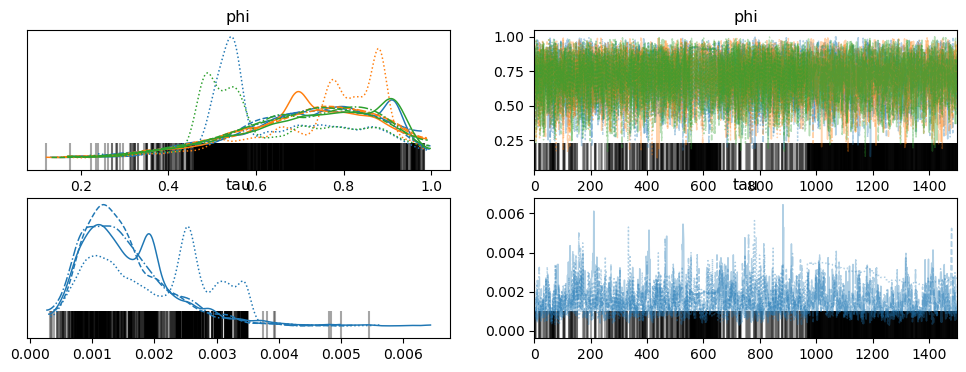

In [5]:
az.plot_trace(trace, var_names=["phi", "tau"]);


4️⃣ Recover sparsity pattern
Posterior mean of loadings

In [6]:
Lambda_post = trace.posterior["Lambda"].mean(dim=("chain", "draw")).values


Heatmap comparison

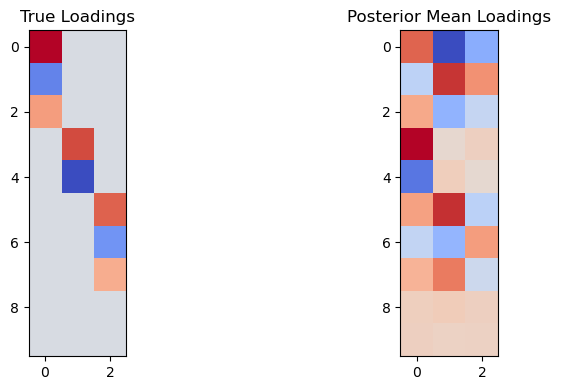

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(Lambda_true, cmap="coolwarm")
axes[0].set_title("True Loadings")

axes[1].imshow(Lambda_post, cmap="coolwarm")
axes[1].set_title("Posterior Mean Loadings")

plt.tight_layout()
plt.show()


5️⃣ Latent factor recovery (up to sign & rotation)

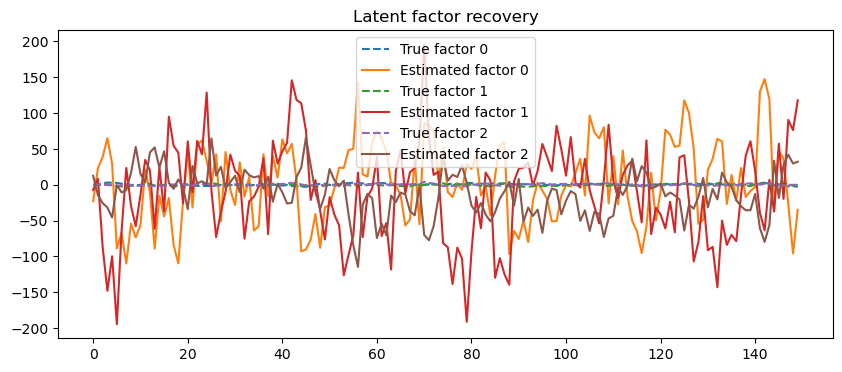

In [8]:
f_post = trace.posterior["f"].mean(dim=("chain", "draw")).values

plt.figure(figsize=(10, 4))
for k in range(k_factors):
    plt.plot(f_true[:, k], label=f"True factor {k}", linestyle="--")
    plt.plot(f_post[:, k], label=f"Estimated factor {k}")
plt.legend()
plt.title("Latent factor recovery")
plt.show()


6️⃣ Notes on identifiability (important ⚠️)

For real data, add at least one of:

Lower-triangular constraint on Lambda

Positive diagonal constraint

Ordered AR coefficients

Fix one loading per factor

Example (optional):

In [9]:
Lambda = pt.set_subtensor(Lambda[0, 1:], 0.0)
Lambda = pt.set_subtensor(Lambda[1, 2:], 0.0)
